# 05 — SRCNN Baseline

**Goal:** Train and evaluate Super-Resolution Convolutional Neural Network (SRCNN) as Baseline 1.


In [7]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import rasterio
from pathlib import Path
from skimage.transform import resize as sk_resize
from tqdm import tqdm

sys.path.insert(0, "..")
from metrics import psnr, ssim, enl, normalise, evaluate_arrays, print_results

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Configuration

All tuneable parameters in one place.

In [8]:
BASE_DIR = '/kaggle/input/datasets/vinhnh96/stac-dataset'

BASE_WORK_DIR = '/kaggle/working'

DATASET_DIR  = Path(BASE_DIR + "/stac_dataset")

CKPT_DIR     = Path(BASE_WORK_DIR + "/checkpoints/srcnn")
LOG_DIR      = Path(BASE_WORK_DIR + "/logs/srcnn")
REPORTS_DIR  = Path(BASE_WORK_DIR + "/reports")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

HR_SIZE   = 512   # HR patch side length in pixels
LR_SIZE   = 128   # LR patch side length in pixels
SCALE     = 4     # upscale factor

BATCH_SIZE  = 16
EPOCHS      = 50
LR          = 1e-4   # learning rate
SEED        = 42

# Reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Dataset split

Collect all patch IDs and split into train / val / test at 80/10/10 using seed=42.
This exact split is shared with the SwinIR notebook (Step 4) for fair comparison.

In [9]:
all_hr = sorted(DATASET_DIR.glob("*_HR.tif"))
all_lr = sorted(DATASET_DIR.glob("*_LR.tif"))
assert len(all_hr) == len(all_lr), "HR/LR count mismatch"

n_total = len(all_hr)
indices = np.arange(n_total)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_test = int(n_total * 0.10)
n_val  = int(n_total * 0.10)
n_train = n_total - n_val - n_test

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

print(f"Total patches : {n_total:,}")
print(f"Train         : {len(train_idx):,}")
print(f"Val           : {len(val_idx):,}")
print(f"Test          : {len(test_idx):,}")

Total patches : 6,047
Train         : 4,839
Val           : 604
Test          : 604


## 2. tf.data pipeline

Each sample:
1. Load LR (128x128) and HR (512x512) GeoTIFF patches
2. Normalise both to float32 [0, 1]
3. Bicubic-upsample LR to 512x512 — this is the SRCNN input (following the original paper)
4. Add channel dim: (H, W) -> (H, W, 1)

The pipeline uses `tf.py_function` to wrap rasterio file I/O, then prefetches for GPU throughput.

In [10]:
def load_pair(hr_path_str, lr_path_str):
    """Load one LR/HR pair, normalise, bicubic-upsample LR to HR size."""
    hr_path = hr_path_str.numpy().decode()
    lr_path = lr_path_str.numpy().decode()

    with rasterio.open(hr_path) as src:
        hr = src.read(1).astype(np.float32)
    with rasterio.open(lr_path) as src:
        lr = src.read(1).astype(np.float32)

    # Per-patch normalisation using the HR max (keeps HR/LR on the same scale)
    max_val = hr.max()
    if max_val > 0:
        hr = hr / max_val
        lr = lr / max_val

    # Bicubic upsample LR to 512x512 (SRCNN takes upsampled input)
    lr_up = sk_resize(lr, (HR_SIZE, HR_SIZE), order=3,
                      anti_aliasing=True, preserve_range=True).astype(np.float32)
    lr_up = np.clip(lr_up, 0.0, 1.0)

    # Add channel dim
    lr_up = lr_up[..., np.newaxis]
    hr    = hr[..., np.newaxis]

    return lr_up, hr


def make_dataset(idx_array: np.ndarray, shuffle: bool = False) -> tf.data.Dataset:
    hr_paths = [str(all_hr[i]) for i in idx_array]
    lr_paths = [str(all_lr[i]) for i in idx_array]

    ds = tf.data.Dataset.from_tensor_slices((hr_paths, lr_paths))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(idx_array), seed=SEED)

    ds = ds.map(
        lambda hr, lr: tf.py_function(
            func=load_pair,
            inp=[hr, lr],
            Tout=[tf.float32, tf.float32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.map(lambda lr, hr: (tf.ensure_shape(lr, [HR_SIZE, HR_SIZE, 1]),
                                tf.ensure_shape(hr, [HR_SIZE, HR_SIZE, 1])))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_idx, shuffle=True)
val_ds   = make_dataset(val_idx)
test_ds  = make_dataset(test_idx)

# Sanity check one batch
for lr_batch, hr_batch in train_ds.take(1):
    print(f"LR batch shape : {lr_batch.shape}  dtype={lr_batch.dtype}  range=[{lr_batch.numpy().min():.3f}, {lr_batch.numpy().max():.3f}]")
    print(f"HR batch shape : {hr_batch.shape}  dtype={hr_batch.dtype}  range=[{hr_batch.numpy().min():.3f}, {hr_batch.numpy().max():.3f}]")

LR batch shape : (16, 512, 512, 1)  dtype=<dtype: 'float32'>  range=[0.003, 0.682]
HR batch shape : (16, 512, 512, 1)  dtype=<dtype: 'float32'>  range=[0.000, 1.000]


## 3. Bicubic baseline

Before training anything, establish the bicubic interpolation floor on the test set.
SRCNN must beat these numbers to justify its existence.

In [11]:
y_true_bicubic = []
y_pred_bicubic = []

for idx in tqdm(test_idx, desc="Bicubic baseline"):
    with rasterio.open(all_hr[idx]) as src:
        hr = src.read(1).astype(np.float32)
    with rasterio.open(all_lr[idx]) as src:
        lr = src.read(1).astype(np.float32)

    max_val = hr.max()
    if max_val > 0:
        hr = hr / max_val
        lr = lr / max_val

    lr_up = sk_resize(lr, (HR_SIZE, HR_SIZE), order=3,
                      anti_aliasing=True, preserve_range=True).astype(np.float32)
    lr_up = np.clip(lr_up, 0.0, 1.0)

    y_true_bicubic.append(hr)
    y_pred_bicubic.append(lr_up)

bicubic_results = evaluate_arrays(y_true_bicubic, y_pred_bicubic)
print_results(bicubic_results, "Bicubic baseline (test set)")

Bicubic baseline: 100%|██████████| 604/604 [00:47<00:00, 12.75it/s]



Bicubic baseline (test set)
------------------------------------
  PSNR      : 29.6045 dB
  SSIM      : 0.6098
  ENL pred  : 34.8928
  ENL true  : 9.6503
------------------------------------


## 4. SRCNN model

In [12]:
def build_srcnn(input_shape=(HR_SIZE, HR_SIZE, 1)) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=input_shape, name="lr_upsampled")

    x = tf.keras.layers.Conv2D(64, (9, 9), padding="same", activation="relu", name="conv1")(inputs)
    x = tf.keras.layers.Conv2D(32, (1, 1), padding="same", activation="relu", name="conv2")(x)
    x = tf.keras.layers.Conv2D(1,  (5, 5), padding="same", activation="sigmoid", name="conv3")(x)

    return tf.keras.Model(inputs=inputs, outputs=x, name="SRCNN")


model = build_srcnn()
model.summary()

Model: "SRCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lr_upsampled (InputLayer)       │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 512, 512, 64)   │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 512, 512, 32)   │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 512, 512, 1)    │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129 (31.75 KB)

 Trainable params: 8,129 (31.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss=tf.keras.losses.MeanAbsoluteError(),
    metrics=[tf.keras.metrics.MeanSquaredError(name="mse")],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_DIR / "best.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(LOG_DIR),
        histogram_freq=0,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/50


I0000 00:00:1775919636.272183     250 service.cc:152] XLA service 0x7ececc087150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775919636.272223     250 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775919636.272227     250 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775919637.177510     250 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-11 15:00:53.233234: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng1{k2=2,k3=0} for conv %cudnn-conv-bw-filter.5 = (f32[1,32,5,5]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,512,512]{3,2,1,0} %bitcast.1619, f32[16,1,512,512]{3,2,1,0} %bitcast.1683), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/SRCNN_1/conv3_1/convolution/Conv2DBackpropFilter" sourc

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2513 - mse: 0.0853   
Epoch 1: val_loss improved from inf to 0.08739, saving model to /kaggle/working/checkpoints/srcnn/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - loss: 0.2511 - mse: 0.0853 - val_loss: 0.0874 - val_mse: 0.0107 - learning_rate: 1.0000e-04
Epoch 2/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - loss: 0.0564 - mse: 0.0053
Epoch 2: val_loss improved from 0.08739 to 0.03581, saving model to /kaggle/working/checkpoints/srcnn/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 155s 511ms/step - loss: 0.0563 - mse: 0.0053 - val_loss: 0.0358 - val_mse: 0.0027 - learning_rate: 1.0000e-04
Epoch 3/50
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.0357 - mse: 0.0027
Epoch 3: val_loss improved from 0.03581 to 0.03333, saving model to /kaggle/working/checkpoints/srcnn/best.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 153s 506ms/step - loss: 0.0357 - mse: 0.0027 - val_loss: 0.0333 - val_mse: 0.0026 - learning_rate: 1.0000e-0

302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - loss: 0.2554 - mse: 0.0870
Epoch 1: val_loss improved from None to 0.12390, saving model to ../data/checkpoints/srcnn/best.weights.h5

Epoch 1: finished saving model to ../data/checkpoints/srcnn/best.weights.h5
302/302 ━━━━━━━━━━━━━━━━━━━━ 133s 429ms/step - loss: 0.2151 - mse: 0.0657 - val_loss: 0.1239 - val_mse: 0.0216 - learning_rate: 1.0000e-04
Epoch 2/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - loss: 0.0768 - mse: 0.0097
Epoch 2: val_loss improved from 0.12390 to 0.03958, saving model to ../data/checkpoints/srcnn/best.weights.h5

Epoch 2: finished saving model to ../data/checkpoints/srcnn/best.weights.h5
302/302 ━━━━━━━━━━━━━━━━━━━━ 127s 420ms/step - loss: 0.0571 - mse: 0.0058 - val_loss: 0.0396 - val_mse: 0.0030 - learning_rate: 1.0000e-04
Epoch 3/50
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - loss: 0.0378 - mse: 0.0029
Epoch 3: val_loss improved from 0.03958 to 0.03467, saving model to ../data/checkpoints/srcnn/best.weights.h5

Ep

## 6. Training curves

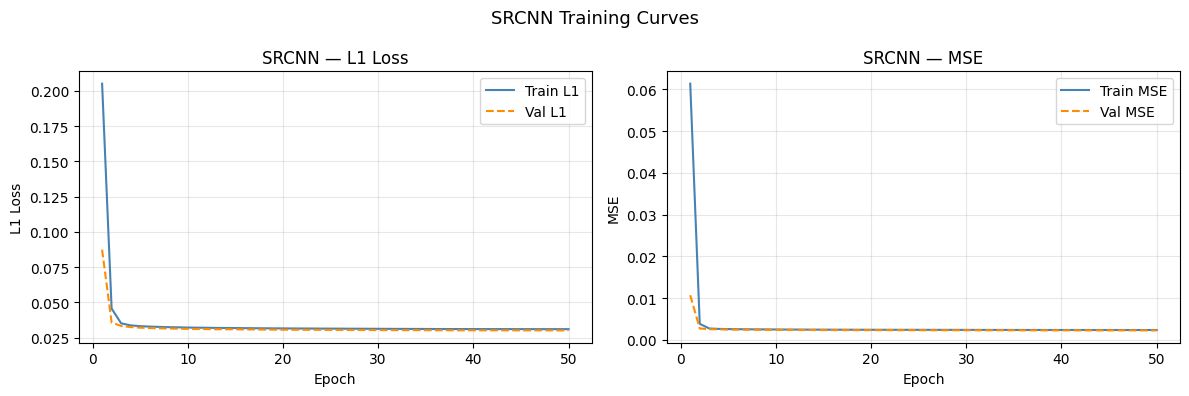

Saved: reports/fig_04_srcnn_training_curves.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(history.history["loss"]) + 1)

ax1.plot(epochs_ran, history.history["loss"],     label="Train L1", color="steelblue")
ax1.plot(epochs_ran, history.history["val_loss"], label="Val L1",   color="darkorange", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("L1 Loss")
ax1.set_title("SRCNN — L1 Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history.history["mse"],     label="Train MSE", color="steelblue")
ax2.plot(epochs_ran, history.history["val_mse"], label="Val MSE",   color="darkorange", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE")
ax2.set_title("SRCNN — MSE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("SRCNN Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "fig_04_srcnn_training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_04_srcnn_training_curves.png")

## 7. Test set evaluation

In [15]:
y_true_list = []
y_pred_list = []

for lr_batch, hr_batch in tqdm(test_ds, desc="Evaluating on test set"):
    preds = model(lr_batch, training=False).numpy()
    hrs   = hr_batch.numpy()
    for pred, hr in zip(preds, hrs):
        y_pred_list.append(np.squeeze(pred))
        y_true_list.append(np.squeeze(hr))

srcnn_results = evaluate_arrays(y_true_list, y_pred_list)

print_results(bicubic_results, "Bicubic baseline  (test set)")
print_results(srcnn_results,   "SRCNN             (test set)")

print("\nImprovement over bicubic:")
print(f"  PSNR  delta : {srcnn_results['psnr'] - bicubic_results['psnr']:+.4f} dB")
print(f"  SSIM  delta : {srcnn_results['ssim'] - bicubic_results['ssim']:+.4f}")
print(f"  ENL   delta : {srcnn_results['enl_pred'] - bicubic_results['enl_pred']:+.4f}")

Evaluating on test set: 100%|██████████| 38/38 [00:15<00:00,  2.38it/s]



Bicubic baseline  (test set)
------------------------------------
  PSNR      : 29.6045 dB
  SSIM      : 0.6098
  ENL pred  : 34.8928
  ENL true  : 9.6503
------------------------------------

SRCNN             (test set)
------------------------------------
  PSNR      : 29.9578 dB
  SSIM      : 0.6558
  ENL pred  : 21.8782
  ENL true  : 9.6503
------------------------------------

Improvement over bicubic:
  PSNR  delta : +0.3533 dB
  SSIM  delta : +0.0460
  ENL   delta : -13.0146


## 8. Sample output grid

Visual comparison: LR input (bicubic-upsampled) | SRCNN output | HR ground truth  
All displayed with log1p normalisation to handle SAR dynamic range.

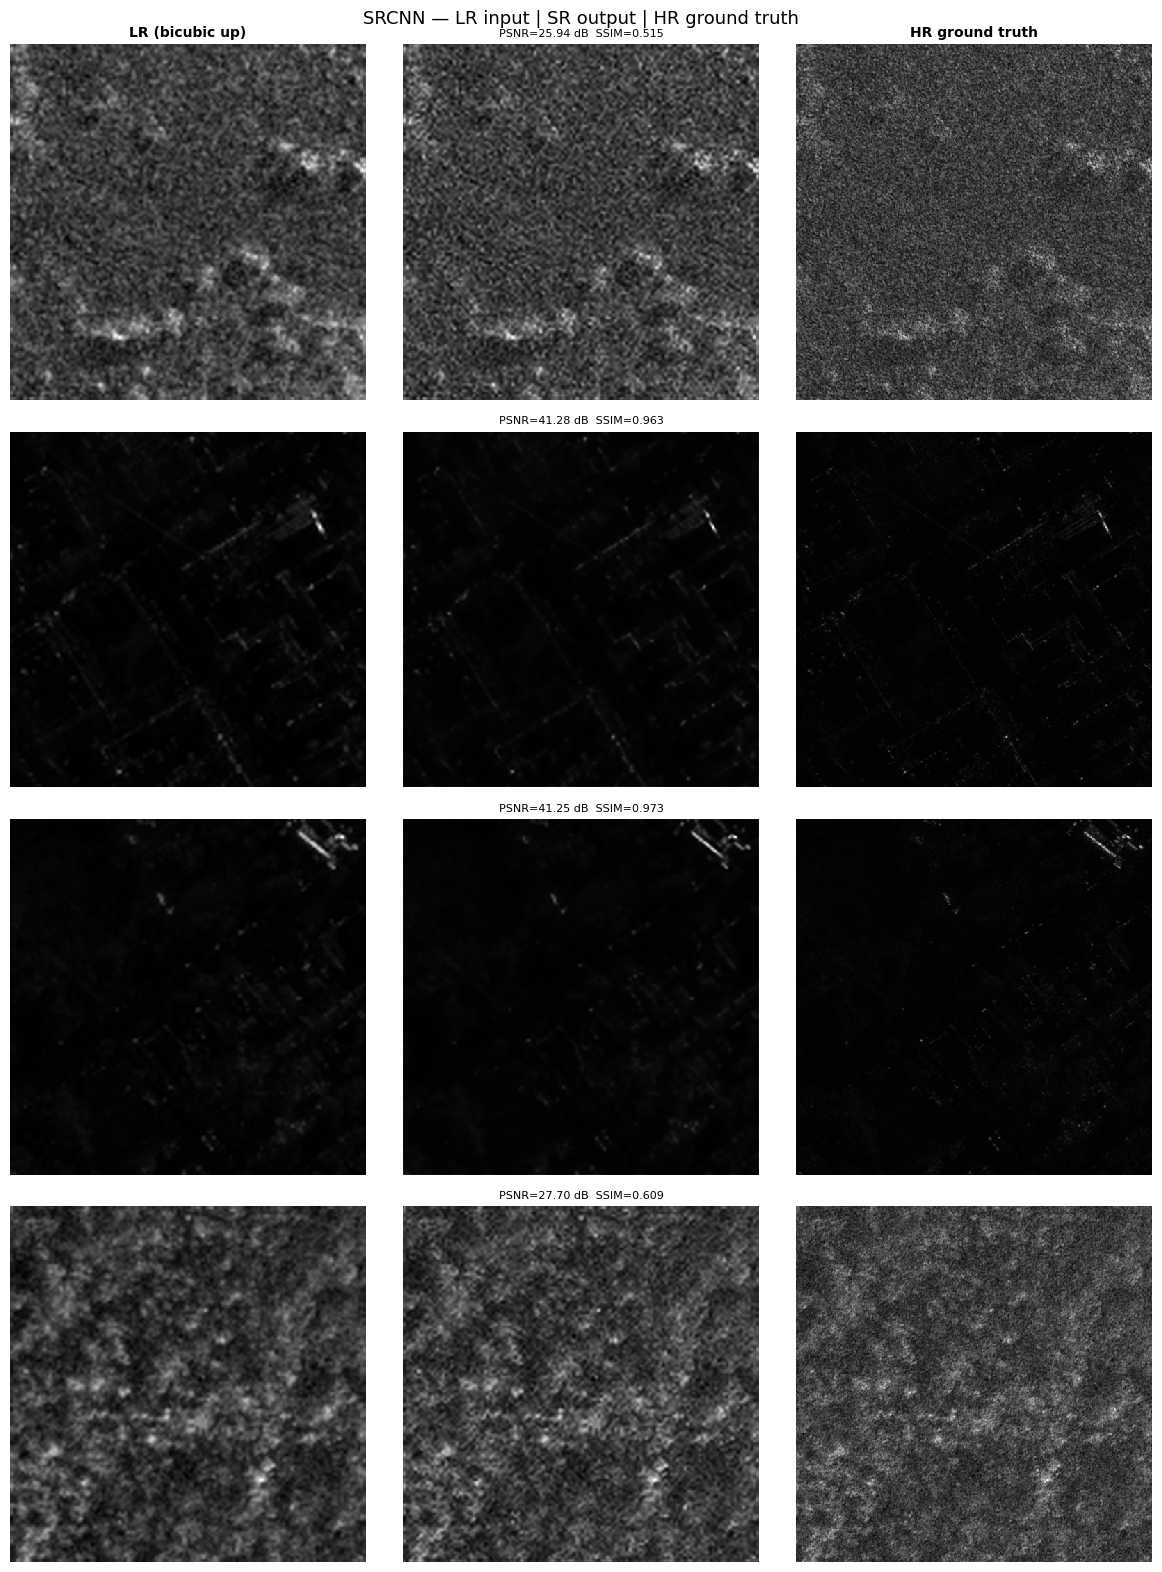

Saved: reports/fig_05_srcnn_sample_outputs.png


In [16]:
def log_display(arr: np.ndarray) -> np.ndarray:
    arr = np.log1p(arr)
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr


N_SHOW = 4
show_idx = np.random.default_rng(SEED).choice(len(test_idx), size=N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, N_SHOW * 4))
fig.suptitle("SRCNN — LR input | SR output | HR ground truth", fontsize=13)

col_titles = ["LR (bicubic up)", "SRCNN output", "HR ground truth"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight="bold")

for row, sample_i in enumerate(show_idx):
    lr_in  = y_true_list[sample_i]   # y_true is HR; we need the LR
    sr_out = y_pred_list[sample_i]
    hr_gt  = y_true_list[sample_i]

    # Reload LR for display (y_pred is SR output not LR)
    orig_idx = test_idx[sample_i]
    with rasterio.open(all_lr[orig_idx]) as src:
        lr_raw = src.read(1).astype(np.float32)
    with rasterio.open(all_hr[orig_idx]) as src:
        hr_raw = src.read(1).astype(np.float32)
    max_val = hr_raw.max()
    lr_raw = lr_raw / max_val if max_val > 0 else lr_raw
    lr_up_disp = sk_resize(lr_raw, (HR_SIZE, HR_SIZE), order=3,
                           anti_aliasing=True, preserve_range=True)

    for col, img in enumerate([lr_up_disp, sr_out, hr_gt]):
        axes[row, col].imshow(log_display(img), cmap="gray", interpolation="nearest")
        axes[row, col].axis("off")

    psnr_val = psnr(hr_gt, sr_out)
    ssim_val = ssim(hr_gt, sr_out)
    axes[row, 1].set_title(f"PSNR={psnr_val:.2f} dB  SSIM={ssim_val:.3f}", fontsize=8)

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "fig_05_srcnn_sample_outputs.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved: reports/fig_05_srcnn_sample_outputs.png")